In [1]:
# Importações

import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os
import scipy.stats as stat
from scipy.stats import iqr as IQR
import collections

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Busca dos dados que serão usados

df_ford = pd.read_csv(fr".\data\ford-specifications.csv")
df_honda = pd.read_csv(fr".\data\honda-specifications.csv")
df_huyndai = pd.read_csv(fr".\data\hyundai-specifications.csv")

In [3]:
# Concatenação dos dados

df = pd.concat([df_ford, df_honda, df_huyndai])
print(df)

        make            model                           variant  yearFrom  \
0       FORD  2010Ford Taurus      3.5L V6 Duratec 6AT (263 HP)       NaN   
1       FORD  2010Ford Taurus  3.5L V6 Duratec 6AT AWD (263 HP)       NaN   
2       FORD      Anglia 100E                  1.2L 3MT (36 HP)    1953.0   
3       FORD      Anglia 105E                  1.0L 4MT (39 HP)    1959.0   
4       FORD           Bronco               2.8L 3MT AWD (89HP)    1966.0   
..       ...              ...                               ...       ...   
696  HYUNDAI    ix35 / Tucson   2.4L Dual CVVT 6AT AWD (176 HP)    2009.0   
697  HYUNDAI    ix35 / Tucson   2.4L Dual CVVT FWD 6AT (176 HP)    2009.0   
698  HYUNDAI  ix55 / Veracruz         3.0L V6 CRDi 6AT (239 HP)    2009.0   
699  HYUNDAI  ix55 / Veracruz         3.0L V6 CRDi 6AT (250 HP)    2009.0   
700  HYUNDAI  ix55 / Veracruz         3.8L V6 DOHC 6AT (264 HP)    2009.0   

     yearTo  bodyType  doors  seats  engineCode  engineDisplacement  ...  \

In [ ]:
# Visualizando os dados

df.to_csv('dados_carros.csv')
# print(df.head())
# print(df.info())
# print(df.describe)
print(df.columns)

Index(['make', 'model', 'variant', 'yearFrom', 'yearTo', 'engineFuelType',
       'enginePowerBhp', 'enginePowerKw', 'gearboxType', 'gears', 'drivetrain',
       'topSpeedKph', 'fuelTankLitres', 'lengthMm', 'widthMm', 'heightMm',
       'texto', 'cluster', 'segmento'],
      dtype='object')


: 

In [5]:
# Tratando os data frames 

columns = [
    'make',
    'model',
    'variant',
    'yearFrom',
    'yearTo',
    'engineFuelType',
    'enginePowerBhp',
    'enginePowerKw',
    'gearboxType',
    'gears',
    'drivetrain',
    'topSpeedKph',
    'fuelTankLitres',
    'lengthMm', 
    'widthMm',
    'heightMm'
]

df = df[columns]
print(df.info())
print(df.head(10))
print(df.isnull().sum())
print(df.isna().sum())

df['texto'] = (
    df[columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

print(df['texto'].head())


<class 'pandas.core.frame.DataFrame'>
Index: 2767 entries, 0 to 700
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   make            2767 non-null   object 
 1   model           2767 non-null   object 
 2   variant         2767 non-null   object 
 3   yearFrom        2753 non-null   float64
 4   yearTo          1955 non-null   float64
 5   engineFuelType  2679 non-null   object 
 6   enginePowerBhp  2701 non-null   float64
 7   enginePowerKw   2701 non-null   float64
 8   gearboxType     2710 non-null   object 
 9   gears           2537 non-null   float64
 10  drivetrain      2372 non-null   object 
 11  topSpeedKph     2089 non-null   float64
 12  fuelTankLitres  2049 non-null   float64
 13  lengthMm        2710 non-null   float64
 14  widthMm         2708 non-null   float64
 15  heightMm        2694 non-null   float64
dtypes: float64(10), object(6)
memory usage: 367.5+ KB
None
   make            model     

In [6]:
# Vendo outliers

df_numbers = df.select_dtypes(include=np.number).copy()

def Q1(x, axis=0):
    return np.percentile(x, 25, axis=axis)

def Q3(x, axis=0):
    return np.percentile(x, 75, axis=axis)

def IQR_outlier(x, axis=0, bar=1.5, side='both'):
    assert side in ['gt', 'lt', 'both'], 'Side should be `gt`, `lt` or `both`.'

    d_IQR = IQR(x, axis=axis)
    d_Q1 = Q1(x, axis=axis)
    d_Q3 = Q3(x, axis=axis)
    IQR_distance = np.multiply(d_IQR, bar)

    stat_shape = list(x.shape)
    stat_shape[axis] = 1

    if side in ['gt', 'both']:
        upper_range = d_Q3 + IQR_distance
        upper_outlier = np.greater(x - upper_range.reshape(stat_shape), 0)
    if side in ['lt', 'both']:
        lower_range = d_Q1 - IQR_distance
        lower_outlier = np.less(x - lower_range.reshape(stat_shape), 0)

    if side == 'gt':
        return upper_outlier
    if side == 'lt':
        return lower_outlier
    return np.logical_or(upper_outlier, lower_outlier)

outlier_mask = pd.DataFrame(
    IQR_outlier(df_numbers, axis=0),
    index=df_numbers.index,
    columns=df_numbers.columns
)

print(outlier_mask.sum().sort_values(ascending=False))

# Linhas que possuem pelo menos um outlier
print(df_numbers.loc[outlier_mask.any(axis=1)])

yearFrom          0
yearTo            0
enginePowerBhp    0
enginePowerKw     0
gears             0
topSpeedKph       0
fuelTankLitres    0
lengthMm          0
widthMm           0
heightMm          0
dtype: int64
Empty DataFrame
Columns: [yearFrom, yearTo, enginePowerBhp, enginePowerKw, gears, topSpeedKph, fuelTankLitres, lengthMm, widthMm, heightMm]
Index: []


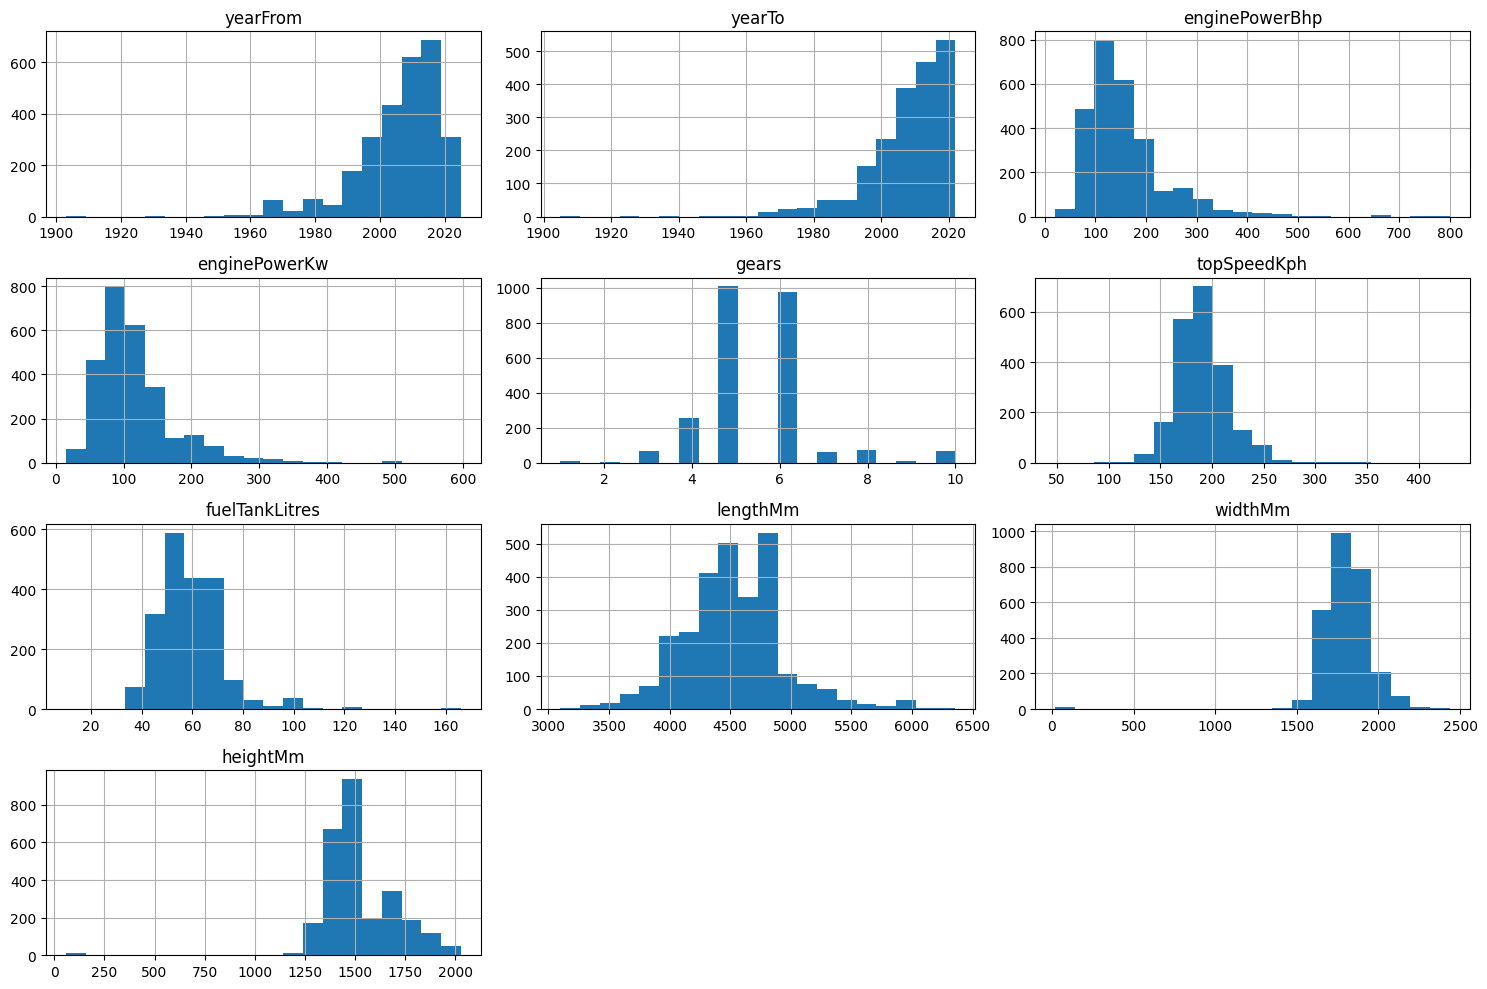

In [7]:
# ver o histograma serve para indentificar a distribuição deles

# Parece haver um bom número de outliers
df_numbers.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

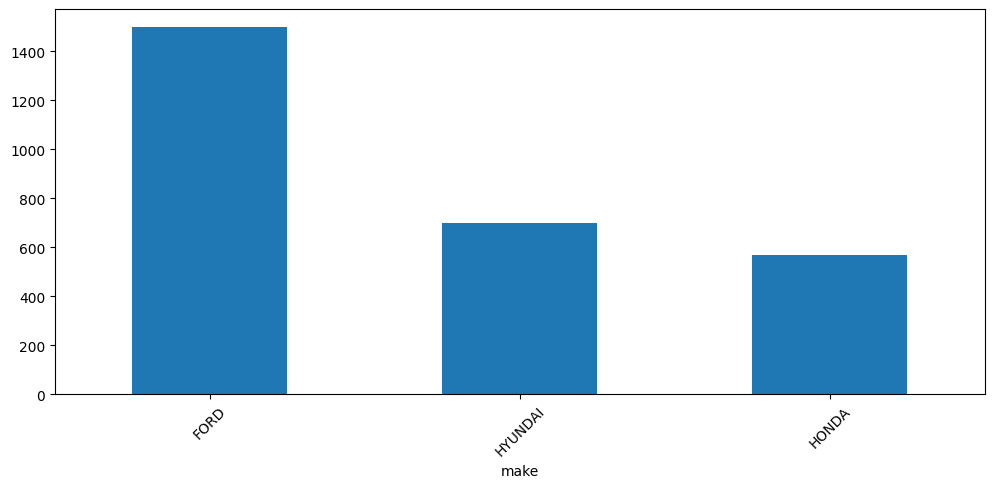

In [8]:
# Plotando densidade 

plt.figure(figsize=(12,5))

df['make'].value_counts().head(15).plot(kind='bar')

plt.xticks(rotation=45)

plt.show()

In [9]:
# # Plotando densidade 

# plt.figure(figsize=(15, 10))

# for i, col in enumerate(columns, 1):
#     plt.subplot(len(num_cols)//3 + 1, 3, i)
#     sns.kdeplot(df[col], fill=True)
#     plt.title(f'Densidade de {col}')

# plt.tight_layout()
# plt.show()

In [10]:
model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

embeddings = model.encode(
    df['texto'].tolist(),
    show_progress_bar=True
)

print(embeddings.shape)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

labels = kmeans.fit_predict(
    embeddings
)

df['cluster'] = labels

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Batches: 100%|██████████| 87/87 [00:13<00:00,  6.58it/s]


(2767, 384)


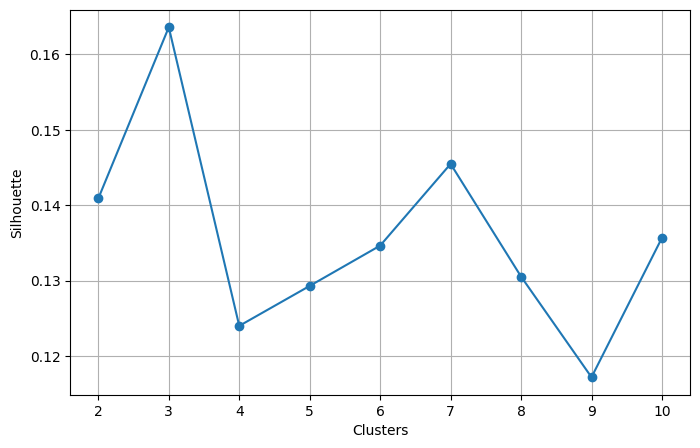

In [11]:
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        embeddings
    )

    score = silhouette_score(
        embeddings,
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Silhouette")

plt.grid()

plt.show()

In [ ]:
# stats_cluster = (
#     columns = [
#     'make',
#     'model',
#     'variant',
#     'yearFrom',
#     'yearTo',
#     'engineFuelType',
#     'enginePowerBhp',
#     'enginePowerKw',
#     'gearboxType',
#     'gears',
#     'drivetrain',
#     'topSpeedKph',
#     'fuelTankLitres',
#     'lengthMm', 
#     'widthMm',
#     'heightMm'
# ]
#     df.groupby('cluster')
#     .agg(
#         tamanho_cluster=('cluster','count'),

#         model_media=('model','mean'),
#         model_std=('model','std'),

#         make_media=('make','mean'),
#         make_std=('make','std'),

#         mpg_city_media=('MPG_City','mean'),
#         mpg_city_std=('MPG_City','std'),

#         mpg_highway_media=('MPG_Highway','mean'),
#         mpg_highway_std=('MPG_Highway','std'),

#         peso_media=('Weight','mean'),
#         peso_std=('Weight','std'),

#         wheelbase_media=('Wheelbase','mean'),
#         wheelbase_std=('Wheelbase','std'),

#         comprimento_media=('Length','mean'),
#         comprimento_std=('Length','std')
#     )
# )

# print(stats_cluster)

KeyError: "Column(s) ['EngineSize', 'HorsePower', 'Length', 'MPG_City', 'MPG_Highway', 'Weight', 'Wheelbase'] do not exist"

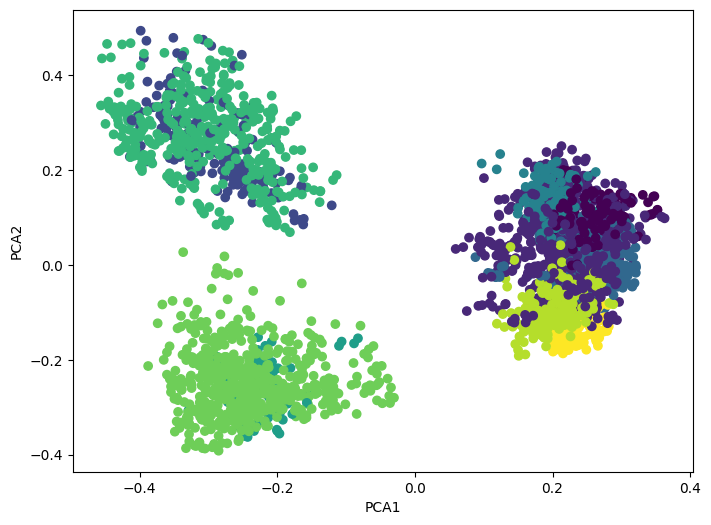

In [13]:

pca = PCA(
    n_components=3
)

X = pca.fit_transform(
    embeddings
)

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

In [14]:
knn = NearestNeighbors(
    n_neighbors=3,
    metric='cosine'
)

knn.fit(embeddings)

,n_neighbors,3
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [16]:

labels = kmeans.fit_predict(
    embeddings)
df['segmento'] = labels
for s in sorted(
    df.segmento.unique()
):

    print(
        f"\nSEGMENTO {s}"
    )

    print(
        df[
            df.segmento==s
        ][[
            'make',
            'model',
            'variant'
        ]].head(10)
    )


SEGMENTO 0
     make              model                     variant
307  FORD              F-150       2.7L EcoBoost V6 10AT
308  FORD              F-150   3.0L Power Stroke V6 10AT
309  FORD              F-150     3.3L Ti-VCT V6 FFV 10AT
310  FORD              F-150       3.5L EcoBoost V6 10AT
311  FORD              F-150     3.5L PowerBoost V6 10AT
315  FORD       F-150 Raptor       3.5L EcoBoost V6 10AT
318  FORD  F-150 Regular Cab  3.5L V6 EcoBoost 6AT (4x2)
319  FORD  F-150 Regular Cab  3.5L V6 EcoBoost 6AT (4x4)
320  FORD  F-150 Regular Cab       3.7L V6 FFV 6AT (4x2)
321  FORD  F-150 Regular Cab       3.7L V6 FFV 6AT (4x4)

SEGMENTO 1
   make            model                           variant
0  FORD  2010Ford Taurus      3.5L V6 Duratec 6AT (263 HP)
1  FORD  2010Ford Taurus  3.5L V6 Duratec 6AT AWD (263 HP)
2  FORD      Anglia 100E                  1.2L 3MT (36 HP)
3  FORD      Anglia 105E                  1.0L 4MT (39 HP)
4  FORD           Bronco               2.8L 3MT AWD (8

In [17]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)

print(
    "Silhouette:",
    silhouette_score(
        embeddings,
        labels
    )
)

print(
    "Davies:",
    davies_bouldin_score(
        embeddings,
        labels
    )
)

print(
    "Calinski:",
    calinski_harabasz_score(
        embeddings,
        labels
    )
)

Silhouette: 0.13568657636642456
Davies: 2.177112022120103
Calinski: 193.76052856445312
